# Introduction

The one thing that must be the same between the two scenarios (with and without TB-ResNets) is generation. This script tests both scenarios to ensure that the generation is the same.

In [ ]:
import pandas as pd 
import caliperpy
import os
import matplotlib.pyplot as plt


def read_bin(filename):
    dk = caliperpy.TransCAD.connect()
    out = None
    try:
        out = dk.GetDataFrameFromBin(filename)
    except Exception as e:
        print(e) # type: ignore
    finally:
        dk.Close()
        caliperpy.TransCAD.disconnect()
    return out

SCENARIO_BASE_FOLDER = r'C:\models\Reno_TDM\scenarios'
SCENARIO_CONTROL = 'base_2022'
SCENARIO_CHANGE = 'base_2022_resnets_dl_f'
PERIODS = ['AM', 'MD', 'PM', 'NT']

purp_list = {
    'W_HBW': ['v0', 'ilvi', 'ilvs', 'ihvi', 'ihvs'],
    'W_HBO': ['v0', 'vi', 'vs'],
    'N_HBSCH': ['v0', 'vi', 'vs'],
    'N_HBSHP': ['v0', 'vi', 'vs'],
    'N_HBSR': ['v0', 'vi', 'vs'],
    'N_HBO': ['v0', 'vi', 'vs']
}

field_list = []

for k in purp_list.keys():
    for v in purp_list[k]:
        field_list.append(f"{k}_{v}")
        
sedata_base = read_bin(os.path.join(SCENARIO_BASE_FOLDER, SCENARIO_CONTROL, 'output', 'sedata', 'scenario_se.bin'))
sedata_chng = read_bin(os.path.join(SCENARIO_BASE_FOLDER, SCENARIO_CHANGE, 'output', 'sedata', 'scenario_se.bin'))

Connecting to TransCAD...
Disconnected from TransCAD!
Connecting to TransCAD...


c:\ProgramData\anaconda3\envs\fhwa_ai2\Lib\site-packages\caliperpy\caliper3.py:1073: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].mask(df[col] == '', None, inplace=True)
c:\ProgramData\anaconda3\envs\fhwa_ai2\Lib\site-packages\caliperpy\caliper3.py:1073: ChainedAssignmentError: A value is being set on a copy of a DataFrame o

Disconnected from TransCAD!


In [2]:
pd.concat([sedata_base[field_list].sum(), sedata_chng[field_list].sum()], axis = 1).style.format('{:,.1f}')

,0,1
W_HBW_v0,"11,009.3","11,009.3"
W_HBW_ilvi,"25,524.5","25,524.5"
W_HBW_ilvs,"16,272.9","16,272.9"
W_HBW_ihvi,"119,742.8","119,742.8"
W_HBW_ihvs,"78,099.4","78,099.4"
W_HBO_v0,"4,209.7","4,209.7"
W_HBO_vi,"52,617.6","52,617.6"
W_HBO_vs,"57,040.2","57,040.2"
N_HBSCH_v0,"3,290.7","3,290.7"
N_HBSCH_vi,"31,901.4","31,901.4"


In [3]:
sedata_base['W_HBW'] = sedata_base['W_HBW_v0'] + sedata_base['W_HBW_ilvi'] + sedata_base['W_HBW_ilvs'] + sedata_base['W_HBW_ihvi'] + sedata_base['W_HBW_ihvs']
sedata_base['W_HBO'] = sedata_base['W_HBO_v0'] + sedata_base['W_HBO_vi'] + sedata_base['W_HBO_vs']
sedata_base['N_HBSCH'] = sedata_base['N_HBSCH_v0'] + sedata_base['N_HBSCH_vi'] + sedata_base['N_HBSCH_vs']
sedata_base['N_HBSHP'] = sedata_base['N_HBSHP_v0'] + sedata_base['N_HBSHP_vi'] + sedata_base['N_HBSHP_vs']
sedata_base['N_HBSR'] = sedata_base['N_HBSR_v0'] + sedata_base['N_HBSR_vi'] + sedata_base['N_HBSR_vs']
sedata_base['N_HBO'] = sedata_base['N_HBO_v0'] + sedata_base['N_HBO_vi'] + sedata_base['N_HBO_vs']

taz_base = sedata_base.groupby('TAZ').agg(W_HBW = ('W_HBW', 'sum'), W_HBO = ('W_HBO', 'sum'), N_HBSCH = ('N_HBSCH', 'sum'), N_HBSHP = ('N_HBSHP', 'sum'), N_HBSR = ('N_HBSR', 'sum'), N_HBO = ('N_HBO', 'sum'))

sedata_chng['W_HBW'] = sedata_chng['W_HBW_v0'] + sedata_chng['W_HBW_ilvi'] + sedata_chng['W_HBW_ilvs'] + sedata_chng['W_HBW_ihvi'] + sedata_chng['W_HBW_ihvs']
sedata_chng['W_HBO'] = sedata_chng['W_HBO_v0'] + sedata_chng['W_HBO_vi'] + sedata_chng['W_HBO_vs']
sedata_chng['N_HBSCH'] = sedata_chng['N_HBSCH_v0'] + sedata_chng['N_HBSCH_vi'] + sedata_chng['N_HBSCH_vs']
sedata_chng['N_HBSHP'] = sedata_chng['N_HBSHP_v0'] + sedata_chng['N_HBSHP_vi'] + sedata_chng['N_HBSHP_vs']
sedata_chng['N_HBSR'] = sedata_chng['N_HBSR_v0'] + sedata_chng['N_HBSR_vi'] + sedata_chng['N_HBSR_vs']
sedata_chng['N_HBO'] = sedata_chng['N_HBO_v0'] + sedata_chng['N_HBO_vi'] + sedata_chng['N_HBO_vs']

taz_chng = sedata_chng.groupby('TAZ').agg(W_HBW = ('W_HBW', 'sum'), W_HBO = ('W_HBO', 'sum'), N_HBSCH = ('N_HBSCH', 'sum'), N_HBSHP = ('N_HBSHP', 'sum'), N_HBSR = ('N_HBSR', 'sum'), N_HBO = ('N_HBO', 'sum'))
taz_compare = taz_base.join(taz_chng, lsuffix = "_base", rsuffix = "_chng")

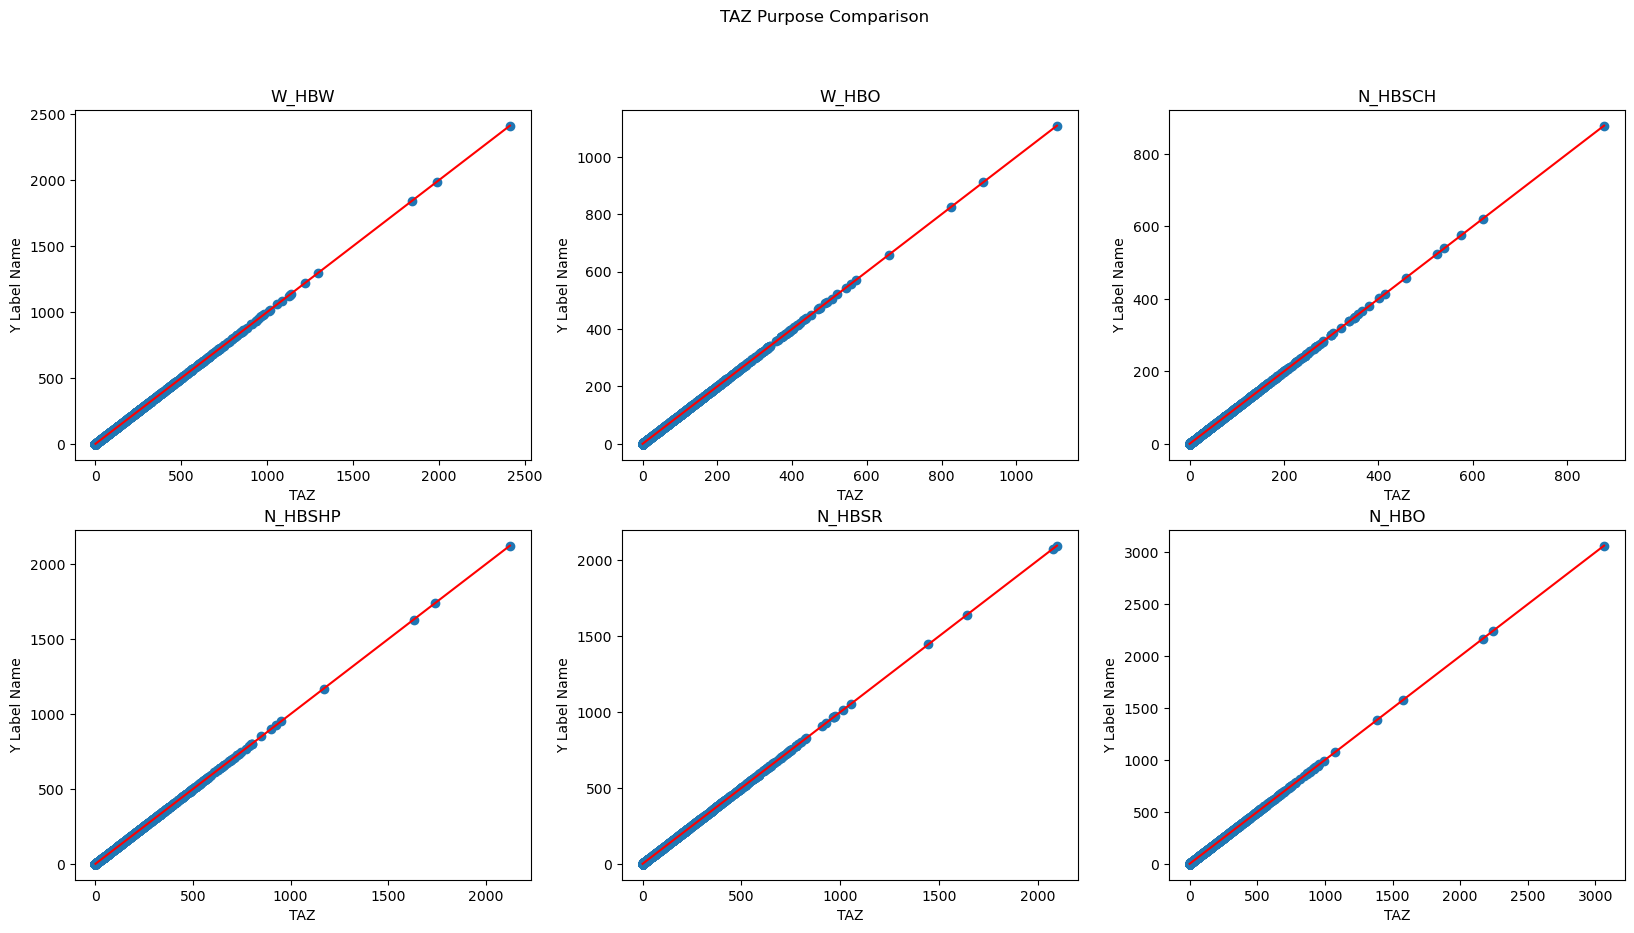

In [4]:
fig, ax = plt.subplots(2, 3, figsize=(20, 10))
plot_idx = 230
cnt = 1
for k in purp_list.keys():
    ax = plt.subplot(plot_idx + cnt)
    axs = ax.scatter(taz_compare[f'{k}_base'], taz_compare[f'{k}_chng'])
    ax.plot([0, axs.axes.dataLim.max[0]], [0, axs.axes.dataLim.max[1]], color = 'red')
    plt.title(f"{k}")
    ax.set_xlabel('TAZ')
    ax.set_ylabel('Y Label Name')
    cnt += 1
plt.suptitle("TAZ Purpose Comparison")
plt.show()

In [5]:
purp_tod_fields = []
for purp in purp_list.keys():
    for vs in purp_list[purp]:
        for per in PERIODS:
            purp_tod_fields.append(f'{purp}_{vs}_{per}')

In [6]:
sedata_base.sort_values('TAZ')[['TAZ', 'N_HBSHP_vs_AM']]

,TAZ,N_HBSHP_vs_AM
324,101,0.000000
585,102,0.000000
584,103,0.000000
310,104,0.000000
583,105,2.675562
...,...,...
1168,3008,0.000000
1167,3009,0.000000
1166,3010,0.000000
1165,3011,0.000000


In [7]:
pd.concat([sedata_base[purp_tod_fields].sum(), sedata_chng[purp_tod_fields].sum()], axis = 1).style.format('{:,.1f}')

,0,1
W_HBW_v0_AM,"1,766.8","1,766.8"
W_HBW_v0_MD,"2,011.4","2,011.4"
W_HBW_v0_PM,"3,369.4","3,369.4"
W_HBW_v0_NT,"3,861.6","3,861.6"
W_HBW_ilvi_AM,"6,151.0","6,151.0"
W_HBW_ilvi_MD,"3,851.5","3,851.5"
W_HBW_ilvi_PM,"6,931.0","6,931.0"
W_HBW_ilvi_NT,"8,591.1","8,591.1"
W_HBW_ilvs_AM,"3,926.4","3,926.4"
W_HBW_ilvs_MD,"2,410.8","2,410.8"
